### A. Load Library 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

load_dotenv('../ingestion/.env')  # reuse .env to prevent leak
os.getcwd()

'c:\\Users\\Alvin\\Music\\project_1\\notebook'

In [2]:
# Koneksi ke Postgres, baca langsung dari tabel marts hasil dbt
DB_USER = os.getenv("DB_USER", "alvin")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "price_intelligence")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

#Schema: 'public' fact table from mart
df_raw = pd.read_sql("SELECT * FROM public.fct_ebay_listings", engine)

print(f"Total baris: {len(df_raw)}")
df_raw.head()

Total baris: 1813


,item_id,title,price,currency,condition,seller_location,volume_number,volume_number_end,is_boxset,boxset_side_story_edition_included,standalone_side_story_edition,is_special_edition,total_risk_score,risk_category,fetched_at
0,v1|115965603147|0,Spy Classroom Volumes 1-3 Light Novel Set New ...,40.50,USD,Brand New,US,1.0,3.0,True,False,False,False,0,Low Risk,2026-08-07 16:24:49.572937
1,v1|116263745717|0,"Gimai Seikatsu, Days with My Step Sister Light...",149.90,USD,Brand New,MY,1.0,8.0,True,False,False,False,70,High Risk,2026-08-07 16:24:49.572937
2,v1|116268231670|0,"Bofuri: I Don't Want to Get Hurt, so I'll Max ...",17.20,USD,Brand New,US,13.0,NaN,False,False,False,False,0,Low Risk,2026-08-07 16:24:49.572937
3,v1|117165076117|0,"Overlord, Vol. 6 (light Novel) : The Men of th...",16.49,USD,Brand New,US,6.0,NaN,False,False,False,False,0,Low Risk,2026-08-07 16:24:49.572937
4,v1|117235695074|0,Classroom of the Elite (Light Novel) Year 1 Vo...,75.00,USD,Good,US,7.0,NaN,False,False,False,False,0,Low Risk,2026-08-07 16:24:49.572937


#### A.1 Checking Data Quality

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1813 entries, 0 to 1812
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   item_id                             1813 non-null   str           
 1   title                               1813 non-null   str           
 2   price                               1813 non-null   float64       
 3   currency                            1813 non-null   str           
 4   condition                           1797 non-null   str           
 5   seller_location                     1813 non-null   str           
 6   volume_number                       1458 non-null   float64       
 7   volume_number_end                   508 non-null    float64       
 8   is_boxset                           1813 non-null   bool          
 9   boxset_side_story_edition_included  1813 non-null   bool          
 10  standalone_side_story_edition      

In [4]:
missing_summary = df_raw.isnull().sum().to_frame('missing_count')
missing_summary['missing_%'] = (missing_summary['missing_count'] / len(df_raw) * 100).round(1)
missing_summary.sort_values('missing_count', ascending=False)

,missing_count,missing_%
volume_number_end,1305,72.0
volume_number,355,19.6
condition,16,0.9
price,0,0.0
title,0,0.0
currency,0,0.0
item_id,0,0.0
seller_location,0,0.0
is_boxset,0,0.0
boxset_side_story_edition_included,0,0.0


In [5]:
print(f"risk_category distribution (all):{df_raw['risk_category'].value_counts()}")

df_price_model = df_raw[df_raw['risk_category'] != 'High Risk']
print(f"risk_category distribution (w/0 high risk): {df_price_model['risk_category'].value_counts()}")

risk_category distribution (all):risk_category
Low Risk     1498
High Risk     315
Name: count, dtype: int64
risk_category distribution (w/0 high risk): risk_category
Low Risk    1498
Name: count, dtype: int64


#### A.2 Price Distribution

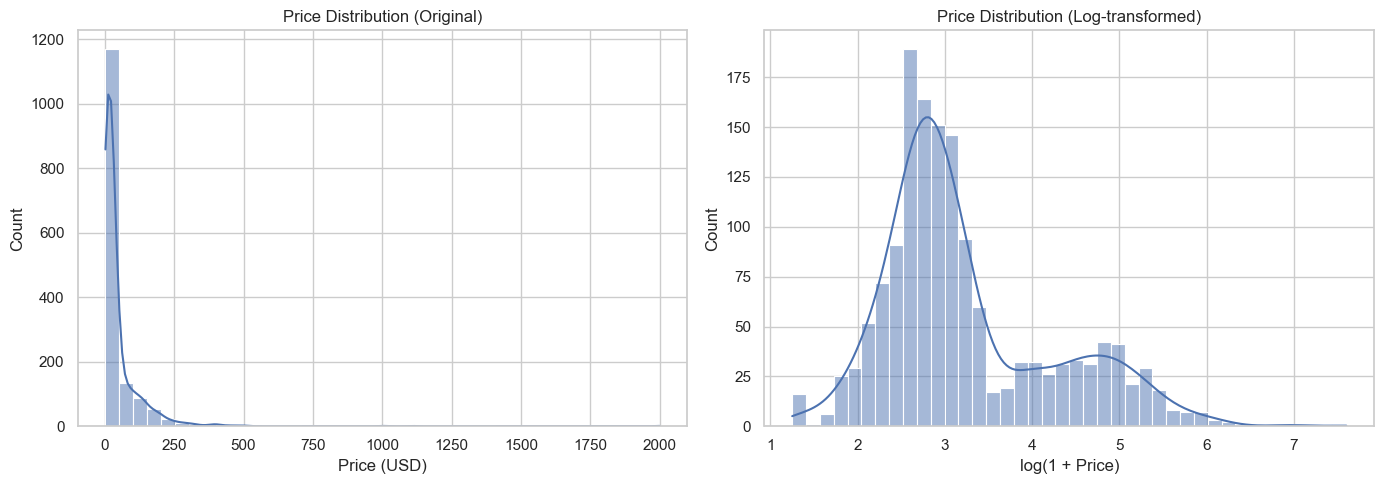

count    1498.000000
mean       46.653625
std        89.634045
min         2.490000
25%        12.950000
50%        17.965000
75%        39.990000
max      1999.000000
Name: price, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_price_model['price'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution (Original)')
axes[0].set_xlabel('Price (USD)')

sns.histplot(np.log1p(df_price_model['price']), bins=40, kde=True, ax=axes[1])
axes[1].set_title('Price Distribution (Log-transformed)')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

print(df_price_model['price'].describe())

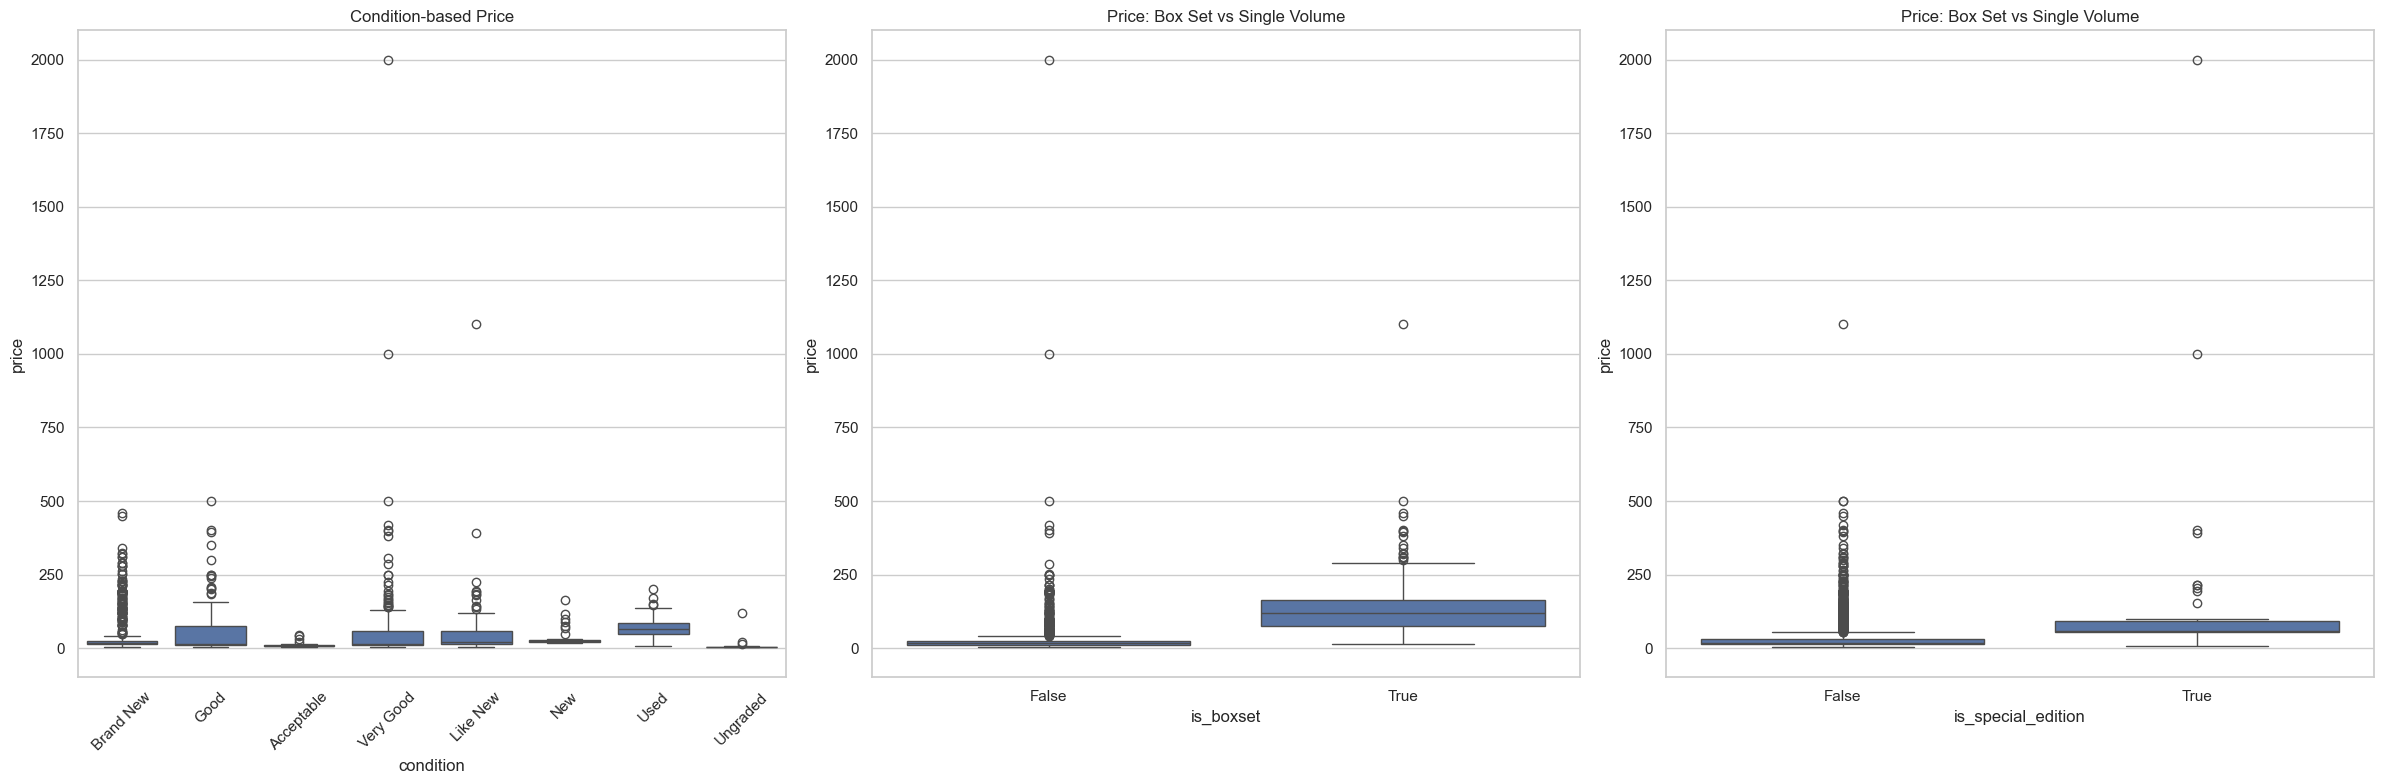

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

sns.boxplot(data=df_price_model, x='condition', y='price', ax=axes[0])
axes[0].set_title('Condition-based Price')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_price_model, x='is_boxset', y='price', ax=axes[1])
axes[1].set_title('Price: Box Set vs Single Volume')

sns.boxplot(data=df_price_model, x='is_special_edition', y='price', ax=axes[2])
axes[2].set_title('Price: Box Set vs Single Volume')

plt.tight_layout()
plt.show()

#### A.3 Feature Engineering

In [8]:
df_model = df_price_model.copy()


df_model['has_volume_info'] = df_model['volume_number'].notna().astype(int)

#### A.4 Cardinality Check

In [9]:
for col in ['condition', 'seller_location']:
    print(f"{col}: {df_model[col].nunique()} kategori unik")
    print(df_model[col].value_counts())
    print()

condition: 8 kategori unik
condition
Brand New     647
Good          283
Very Good     208
Like New      168
New            62
Acceptable     45
Used           41
Ungraded       28
Name: count, dtype: int64

seller_location: 7 kategori unik
seller_location
US    1146
JP     231
MY      46
GB      33
AU      30
CA      11
DE       1
Name: count, dtype: int64



In [10]:
df_model.columns

Index(['item_id', 'title', 'price', 'currency', 'condition', 'seller_location',
       'volume_number', 'volume_number_end', 'is_boxset',
       'boxset_side_story_edition_included', 'standalone_side_story_edition',
       'is_special_edition', 'total_risk_score', 'risk_category', 'fetched_at',
       'has_volume_info'],
      dtype='str')

#### A.5 Preparing Final Feature Set

In [11]:
import numpy as np

def calculate_smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    
    # Avoid division by zero when both y_true and y_pred are 0
    epsilon = 1e-10
    denominator = np.where(denominator == 0, epsilon, denominator)
    
    return np.mean(np.abs(y_pred - y_true) / denominator) * 100

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.compose import TransformedTargetRegressor

numeric_features = df_model.select_dtypes(include=['int', 'float']).columns.tolist()
categorical_features = df_model.select_dtypes(exclude=['int', 'float']).columns.tolist()

# numeric_features = ['volume_number', 'has_volume_info']
# categorical_features = ['condition', 'seller_location', 'is_boxset']

feature_cols = numeric_features + categorical_features
target_col = 'price'

X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 1198, Test: 300


In [13]:
X_train.head(5)

,price,volume_number,volume_number_end,total_risk_score,has_volume_info,item_id,title,currency,condition,seller_location,is_boxset,boxset_side_story_edition_included,standalone_side_story_edition,is_special_edition,risk_category,fetched_at
1364,22.44,9.0,NaN,0,1,v1|377223358303|0,"The Angel Next Door Spoils Me Rotten, Vol. 9 (...",USD,New,US,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937
1526,20.68,3.0,NaN,0,1,v1|397755090287|0,The Eminence in Shadow Vol. 3 (light novel) B...,USD,Brand New,GB,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937
1312,13.36,4.0,NaN,0,1,v1|366543972006|0,"86--Eighty-Six, Vol. 4 (Light Novel) : under P...",USD,Brand New,US,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937
486,12.95,7.0,NaN,0,1,v1|206078678248|0,"86--Eighty-Six, Vol. 7 (Light Novel): Mist Vol...",USD,Brand New,US,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937
1280,18.52,1.0,NaN,0,1,v1|366475769463|0,"The Angel Next Door Spoils Me Rotten, Vol. 1 (...",USD,Brand New,US,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937


In [14]:
X_test.head(5)

,price,volume_number,volume_number_end,total_risk_score,has_volume_info,item_id,title,currency,condition,seller_location,is_boxset,boxset_side_story_edition_included,standalone_side_story_edition,is_special_edition,risk_category,fetched_at
1232,17.06,3.0,NaN,0,1,v1|365659862059|0,RE: Zero -Starting Life in Another World- Shor...,USD,Brand New,US,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937
1567,78.85,26.0,NaN,0,1,v1|398146335656|0,Mushoku Tensei Light Novel Vol 26 Isekai Fanta...,USD,Good,JP,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937
1725,83.37,NaN,NaN,0,0,v1|407125380774|0,Re:ZERO -Starting Life in Another World- Light...,USD,Used,JP,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937
1804,19.99,NaN,NaN,0,0,v1|800455773633|0,Books 1 & 2 the Eminence in Shadow light novel...,USD,Very Good,US,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937
891,16.33,18.0,NaN,0,1,v1|315922457841|0,Mushoku Tensei: Jobless Reincarnation (Light N...,USD,Brand New,US,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937


In [15]:
#Group-Wise median imputation
median_by_boxset = X_train.groupby('is_boxset')['volume_number'].median()
print(median_by_boxset)

X_train['volume_number'] = X_train.apply(
    lambda row: median_by_boxset[row['is_boxset']] if pd.isna(row['volume_number']) else row['volume_number'],
    axis=1
)

X_train['volume_number_end'] = X_train['volume_number_end'].fillna(X_train['volume_number'])
X_train['total_volumes'] = np.where(
        X_train['is_boxset'] & X_train['volume_number_end'].notnull() & X_train['volume_number'].notnull(),
        (X_train['volume_number_end'] - X_train['volume_number'] + 1).clip(lower=1),
        1
)
X_train['vol_x_boxset'] = X_train['total_volumes'] * X_train['is_boxset'].astype(int)
X_train['condition'] = X_train['condition'].fillna('unknown')

#------------------------------------------------------------------------------------------------
X_test['volume_number'] = X_test.apply(
    lambda row: median_by_boxset[row['is_boxset']] if pd.isna(row['volume_number']) else row['volume_number'],
    axis=1
)

X_test['volume_number_end'] = X_test['volume_number_end'].fillna(X_test['volume_number'])
X_test['total_volumes'] = np.where(
        X_test['is_boxset'] & X_test['volume_number_end'].notnull() & X_test['volume_number'].notnull(),
        (X_test['volume_number_end'] - X_test['volume_number'] + 1).clip(lower=1),
        1
)
X_test['vol_x_boxset'] = X_test['total_volumes'] * X_test['is_boxset'].astype(int)
X_test['condition'] = X_test['condition'].fillna('unknown')

# X_train.describe()
X_test.describe()

is_boxset
False    4.0
True     1.0
Name: volume_number, dtype: float64


,price,volume_number,volume_number_end,total_risk_score,has_volume_info,fetched_at,total_volumes,vol_x_boxset
count,300.000000,300.000000,300.000000,300.000000,300.000000,300,300.000000,300.000000
mean,56.190867,4.986667,6.483333,1.150000,0.716667,2026-08-07 16:24:49.572936,2.496667,1.630000
min,2.490000,1.000000,1.000000,0.000000,0.000000,2026-08-07 16:24:49.572937,1.000000,0.000000
25%,12.950000,2.000000,4.000000,0.000000,0.000000,2026-08-07 16:24:49.572937,1.000000,0.000000
50%,18.135000,4.000000,4.000000,0.000000,1.000000,2026-08-07 16:24:49.572937,1.000000,0.000000
75%,46.512500,6.000000,8.000000,0.000000,1.000000,2026-08-07 16:24:49.572937,1.000000,0.000000
max,1999.000000,29.000000,31.000000,30.000000,1.000000,2026-08-07 16:24:49.572937,31.000000,31.000000
std,151.895110,4.617636,5.629716,4.527231,0.451370,NaN,4.722039,5.001649


In [16]:
X_train.head(5)

,price,volume_number,volume_number_end,total_risk_score,has_volume_info,item_id,title,currency,condition,seller_location,is_boxset,boxset_side_story_edition_included,standalone_side_story_edition,is_special_edition,risk_category,fetched_at,total_volumes,vol_x_boxset
1364,22.44,9.0,9.0,0,1,v1|377223358303|0,"The Angel Next Door Spoils Me Rotten, Vol. 9 (...",USD,New,US,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937,1.0,0.0
1526,20.68,3.0,3.0,0,1,v1|397755090287|0,The Eminence in Shadow Vol. 3 (light novel) B...,USD,Brand New,GB,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937,1.0,0.0
1312,13.36,4.0,4.0,0,1,v1|366543972006|0,"86--Eighty-Six, Vol. 4 (Light Novel) : under P...",USD,Brand New,US,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937,1.0,0.0
486,12.95,7.0,7.0,0,1,v1|206078678248|0,"86--Eighty-Six, Vol. 7 (Light Novel): Mist Vol...",USD,Brand New,US,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937,1.0,0.0
1280,18.52,1.0,1.0,0,1,v1|366475769463|0,"The Angel Next Door Spoils Me Rotten, Vol. 1 (...",USD,Brand New,US,False,False,False,False,Low Risk,2026-08-07 16:24:49.572937,1.0,0.0


In [17]:
numeric_features = ['volume_number', 'volume_number_end', 'has_volume_info', 'total_volumes', 'vol_x_boxset']
categorical_features = ['condition', 'seller_location', 'is_boxset', 'currency', 'boxset_side_story_edition_included','standalone_side_story_edition', 'is_special_edition']

feature_cols = numeric_features + categorical_features
target_col = 'price'

X_train = X_train[feature_cols]
X_test = X_test[feature_cols]

X_train.columns
X_test.columns

Index(['volume_number', 'volume_number_end', 'has_volume_info',
       'total_volumes', 'vol_x_boxset', 'condition', 'seller_location',
       'is_boxset', 'currency', 'boxset_side_story_edition_included',
       'standalone_side_story_edition', 'is_special_edition'],
      dtype='str')

#### A.6 Modelling & Evaluating Model Performance

In [18]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder = 'passthrough'
)

def change_model(model_reggressor):
    model = TransformedTargetRegressor(
        regressor=model_reggressor,
        func=np.log1p,       # Applied to 'y' automatically before fitting
        inverse_func=np.expm1 # Applied to predictions automatically
    )

    baseline_pipeline = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    baseline_pipeline.fit(X_train, y_train)
    y_pred = baseline_pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    smape = calculate_smape(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"R^2     : {r2:.3f}")
    print(f"MAE     : {mae:.2f}")
    print(f"RMSE    : {rmse:.2f}")
    print(f"MAPE    : {mape:.3f}")
    print(f"SMAPE   : {smape:.3f}")

    results = pd.DataFrame({
        'Actual': y_test.values if hasattr(y_test, 'values') else y_test,
        'Predicted': y_pred
    })

    results['Residual'] = results['Actual'] - results['Predicted']
    results['Abs_Error'] = np.abs(results['Residual'])
    results['APE (%)'] = (results['Abs_Error'] / results['Actual']) * 100 

    # Tampilkan 10 sampel dengan error terbesar
    display(results.sort_values(by='Abs_Error', ascending=False))

    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot 1: Actual vs Predicted
    axes[0].scatter(results['Actual'], results['Predicted'], alpha=0.5, color='blue')
    axes[0].plot([results['Actual'].min(), results['Actual'].max()], 
                [results['Actual'].min(), results['Actual'].max()], 'r--', lw=2) # Line 45 derajat
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title('Actual vs Predicted')

    # Plot 2: Residual Plot
    axes[1].scatter(results['Predicted'], results['Residual'], alpha=0.5, color='purple')
    axes[1].axhline(y=0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Residual (Actual - Predicted)')
    axes[1].set_title('Residual Plot')

    plt.tight_layout()
    plt.show()

R^2     : 0.071
MAE     : 33.55
RMSE    : 146.17
MAPE    : 0.440
SMAPE   : 40.570


,Actual,Predicted,Residual,Abs_Error,APE (%)
23,1999.00,55.327989,1943.672011,1943.672011,97.232217
258,1099.99,113.002015,986.987985,986.987985,89.726996
104,999.00,55.327989,943.672011,943.672011,94.461663
10,419.99,31.535350,388.454650,388.454650,92.491405
246,399.99,26.855895,373.134105,373.134105,93.285858
...,...,...,...,...,...
91,13.65,13.787537,-0.137537,0.137537,1.007596
185,13.59,13.702390,-0.112390,0.112390,0.827006
244,28.99,29.061081,-0.071081,0.071081,0.245193
278,18.62,18.592023,0.027977,0.027977,0.150255


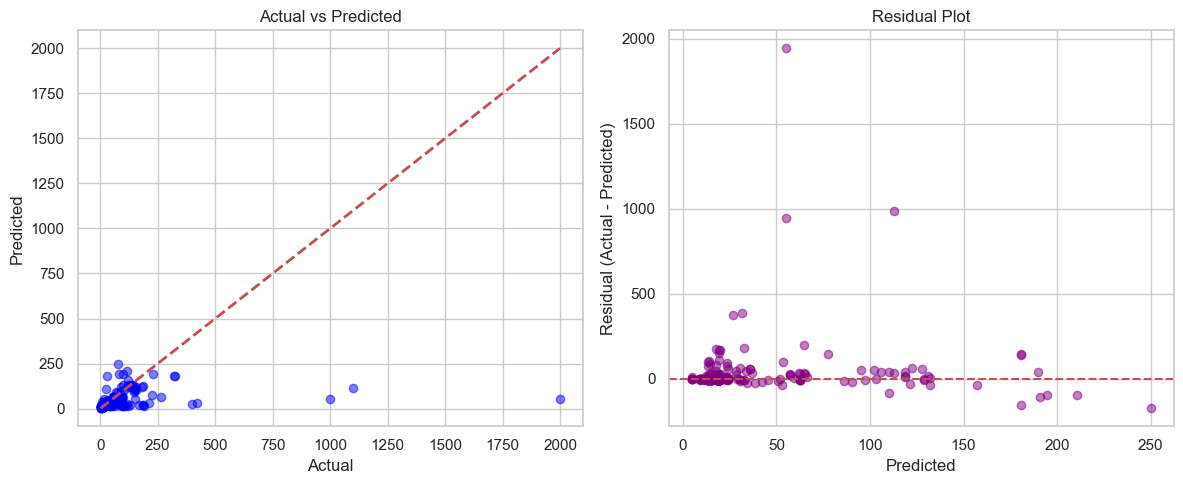

In [19]:
change_model(LinearRegression())

R^2     : 0.134
MAE     : 31.21
RMSE    : 141.08
MAPE    : 0.411
SMAPE   : 39.201


,Actual,Predicted,Residual,Abs_Error,APE (%)
23,1999.00,131.868373,1867.131627,1867.131627,93.403283
258,1099.99,51.522701,1048.467299,1048.467299,95.316075
104,999.00,131.868373,867.131627,867.131627,86.799963
10,419.99,65.708235,354.281765,354.281765,84.354810
246,399.99,62.711672,337.278328,337.278328,84.321690
...,...,...,...,...,...
109,8.64,8.756899,-0.116899,0.116899,1.352998
53,56.79,56.677926,0.112074,0.112074,0.197348
251,19.51,19.463422,0.046578,0.046578,0.238739
291,20.98,20.961179,0.018821,0.018821,0.089708


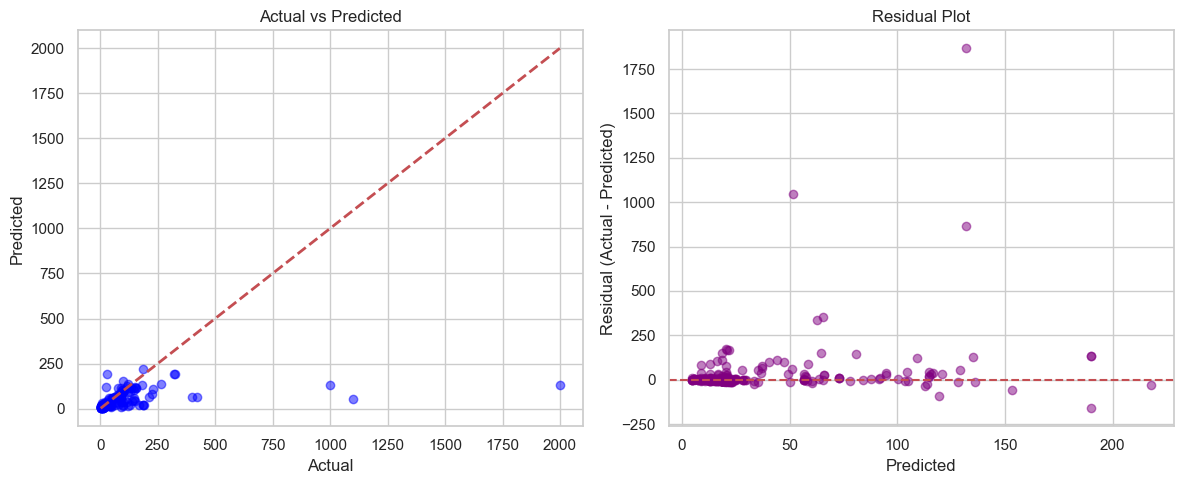

In [20]:
change_model(RandomForestRegressor(random_state=42))

R^2     : 0.169
MAE     : 30.98
RMSE    : 138.27
MAPE    : 0.407
SMAPE   : 38.857


,Actual,Predicted,Residual,Abs_Error,APE (%)
23,1999.00,192.219131,1806.780869,1806.780869,90.384236
258,1099.99,18.876364,1081.113636,1081.113636,98.283951
104,999.00,192.219131,806.780869,806.780869,80.758846
10,419.99,71.136398,348.853602,348.853602,83.062359
246,399.99,69.737579,330.252421,330.252421,82.565169
...,...,...,...,...,...
100,22.38,22.238449,0.141551,0.141551,0.632488
14,12.99,12.914832,0.075168,0.075168,0.578660
88,9.24,9.299002,-0.059002,0.059002,0.638546
291,20.98,20.921568,0.058432,0.058432,0.278513


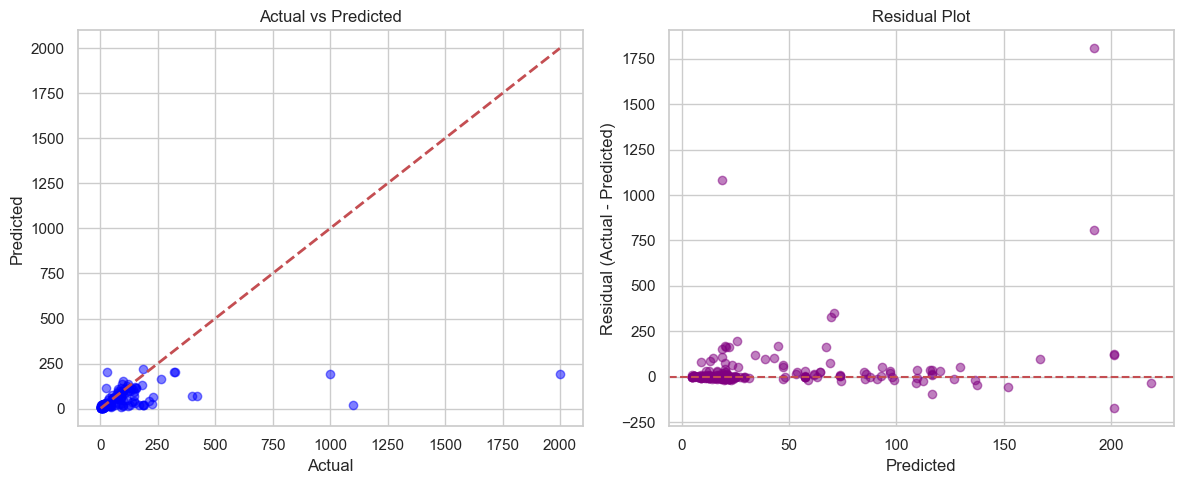

In [21]:
change_model(XGBRegressor(random_state=42))

### B. Implementing OOP

In [24]:
class DataPrep:
    def __init__(self, mart_path, target_column): 
        self.DB_USER = os.getenv("DB_USER", "alvin")
        self.DB_PASSWORD = os.getenv("DB_PASSWORD")
        self.DB_HOST = os.getenv("DB_HOST", "localhost")
        self.DB_PORT = os.getenv("DB_PORT", "5432")
        self.DB_NAME = os.getenv("DB_NAME", "price_intelligence")

        self.engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
        self.target_column = target_column
        self.df_raw = None

    def load_mart(self):
        self.df_raw = pd.readpd.read_sql("SELECT * FROM public.fct_ebay_listings", engine)
        print(f"Total row: {len(df_raw)}")
        display(df_raw.head(5))

